In [1]:
import numpy as np
import pandas as pd
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.formula.api import ols
from statsmodels.stats.anova import anova_lm
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import matplotlib.pyplot as plt

Two-way ANOVA (Type II SS)
                       sum_sq     df        F  PR(>F)
C(group)           30560.4158    1.0  35.1521   0.000
C(time)            47490.5582    8.0   6.8282   0.000
C(group):C(time)     889.8196    8.0   0.1279   0.998
Residual          117365.9893  135.0      NaN     NaN

Holm-Šídák post-hoc: D2 vs 40A per time point
(Welch's t-test; x=0 excluded — both groups fixed at 0)
Time | n_D2 | n_40A |        t |      p_raw |  p_Holm-Šídák | sig
----------------------------------------------------------------------
   1 |    6 |    11 |   2.6910 |     0.0297 |        0.2073 | ns
   2 |    6 |    11 |   4.1933 |     0.0009 |        0.0077 | **
   3 |    6 |    11 |   2.1171 |     0.0524 |        0.2759 | ns
   4 |    6 |    11 |   2.0868 |     0.0557 |        0.2759 | ns
   5 |    6 |    11 |   1.6344 |     0.1236 |        0.3268 | ns
   6 |    6 |    11 |   2.4576 |     0.0286 |        0.2073 | ns
   7 |    6 |    11 |   1.6702 |     0.1240 |        0.3268 | ns
   8 |  

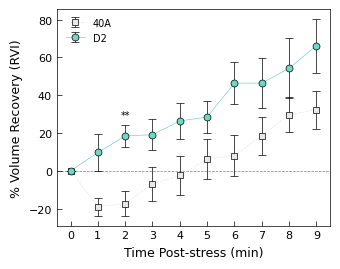

In [4]:
# Load CSV
csv_path = 'Figure_7J_Cell_Volume_Recovery.csv'
df_raw   = pd.read_csv(csv_path, header=0)

cols  = df_raw.columns.tolist()
n_d2  = sum(1 for c in cols if 'D2'  in c)
n_a40 = sum(1 for c in cols if '40A' in c)
df_raw.columns = ['Time'] + [f'D2_{i}'  for i in range(n_d2)] \
                           + [f'40A_{i}' for i in range(n_a40)]
d2_cols  = [c for c in df_raw.columns if c.startswith('D2_')]
a40_cols = [c for c in df_raw.columns if c.startswith('40A_')]

# time=1~10 → x=0~9 (Time Post-stress)
df_rvi         = df_raw[df_raw['Time'] >= 1].copy()
df_rvi['Time'] = df_rvi['Time'] - 1
x_axis = df_rvi['Time'].tolist()

d2_rvi  = [df_rvi[d2_cols].iloc[i].values.astype(float)  for i in range(len(x_axis))]
a40_rvi = [df_rvi[a40_cols].iloc[i].values.astype(float) for i in range(len(x_axis))]

d2_mean  = [np.mean(r) for r in d2_rvi]
d2_sem   = [np.std(r, ddof=1)/np.sqrt(len(r)) for r in d2_rvi]
a40_mean = [np.mean(r) for r in a40_rvi]
a40_sem  = [np.std(r, ddof=1)/np.sqrt(len(r)) for r in a40_rvi]

# Two-way ANOVA (Type II)
rows = []
for t_idx, t in enumerate(x_axis[1:], start=1):
    for val in d2_rvi[t_idx]:
        rows.append({'time': str(t), 'group': 'D2',  'RVI': val})
    for val in a40_rvi[t_idx]:
        rows.append({'time': str(t), 'group': '40A', 'RVI': val})
df_long   = pd.DataFrame(rows)
model     = ols('RVI ~ C(group) + C(time) + C(group):C(time)', data=df_long).fit()
aov_table = anova_lm(model, typ=2)

print("=" * 55)
print("Two-way ANOVA (Type II SS)")
print("=" * 55)
print(aov_table.round(4))

# Holm-Šídák post-hoc (x=1~9)
# Welch's t-test
x_posthoc = x_axis[1:]
pvals = []; tvals = []
for t in x_posthoc:
    t_stat, p = stats.ttest_ind(d2_rvi[t], a40_rvi[t], equal_var=False)
    tvals.append(t_stat); pvals.append(p)

reject, pvals_corr, _, _ = multipletests(pvals, method='holm-sidak')

print("\n" + "=" * 62)
print("Holm-Šídák post-hoc: D2 vs 40A per time point")
print("(Welch's t-test; x=0 excluded — both groups fixed at 0)")
print("=" * 62)
print(f"{'Time':>4} | {'n_D2':>4} | {'n_40A':>5} | {'t':>8} | {'p_raw':>10} | {'p_Holm-Šídák':>13} | sig")
print("-" * 70)
for i, t in enumerate(x_posthoc):
    p   = pvals_corr[i]
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"  {t:2d} | {len(d2_rvi[t]):4d} | {len(a40_rvi[t]):5d} | "
          f"{tvals[i]:8.4f} | {pvals[i]:10.4f} | {pvals_corr[i]:13.4f} | {sig}")

# stats CSV
pd.DataFrame({
    'Time_poststress': x_posthoc,
    'n_D2':            [len(d2_rvi[t]) for t in x_posthoc],
    'n_40A':           [len(a40_rvi[t]) for t in x_posthoc],
    't_statistic':     [round(v,4) for v in tvals],
    'p_raw':           [round(v,4) for v in pvals],
    'p_Holm_Sidak':    [round(v,4) for v in pvals_corr],
    'significant':     ['***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
                        for p in pvals_corr]
}).to_csv('Figure_7J_RVI_stats.csv', index=False)

# Plot
COLOR_D2  = '#6fd8c4'
COLOR_40A = '#e8e8e8'
LW = 0.5; MS = 5; CAPSIZE = 3; CAPTHICK = 0.5; ELINEWIDTH = 0.5

fig, ax = plt.subplots(figsize=(3.5, 2.8))
ax.axhline(0, color='black', linewidth=0.5, linestyle='--', zorder=1, alpha=0.5)

ax.errorbar(x_axis, a40_mean, yerr=a40_sem,
            color=COLOR_40A, ecolor='black', fmt='--s',
            linewidth=LW, markersize=MS, markeredgecolor='black', markeredgewidth=0.5,
            capsize=CAPSIZE, capthick=CAPTHICK, elinewidth=ELINEWIDTH,
            label='40A', zorder=2)
ax.errorbar(x_axis, d2_mean, yerr=d2_sem,
            color=COLOR_D2, ecolor='black', fmt='-o',
            linewidth=LW, markersize=MS, markeredgecolor='black', markeredgewidth=0.5,
            capsize=CAPSIZE, capthick=CAPTHICK, elinewidth=ELINEWIDTH,
            label='D2', zorder=3)

for i, t in enumerate(x_posthoc):
    p = pvals_corr[i]
    if p < 0.05:
        sym   = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
        y_top = max(d2_mean[t] + d2_sem[t], a40_mean[t] + a40_sem[t]) + 3
        ax.text(t, y_top, sym, ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Time Post-stress (min)', fontsize=9)
ax.set_ylabel('% Volume Recovery (RVI)', fontsize=9)
ax.set_xlim(-0.5, 9.5)
ax.set_xticks(x_axis)
ax.tick_params(axis='both', which='both', direction='in', width=0.5, labelsize=8)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)
ax.legend(fontsize=7, frameon=False)
plt.tight_layout()

plt.savefig('Figure_7J_RVI.pdf', dpi=300, bbox_inches='tight')
print("\nSaved: Figure_7J_RVI.pdf / .png / _stats.csv")
plt.show()
